# Interprétabilité — Grad-CAM

Visualise les régions activantes du modèle final EfficientNet-B0 sur quelques images du **test set final**.

Méthode : Grad-CAM appliquée à la dernière couche convolutive du backbone (`model.features[-1]`).

Les visualisations sont sauvegardées dans `results/efficientnet/gradcam/`.

/media/DATA/Projects/bellinna/Zoidberg2.0/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


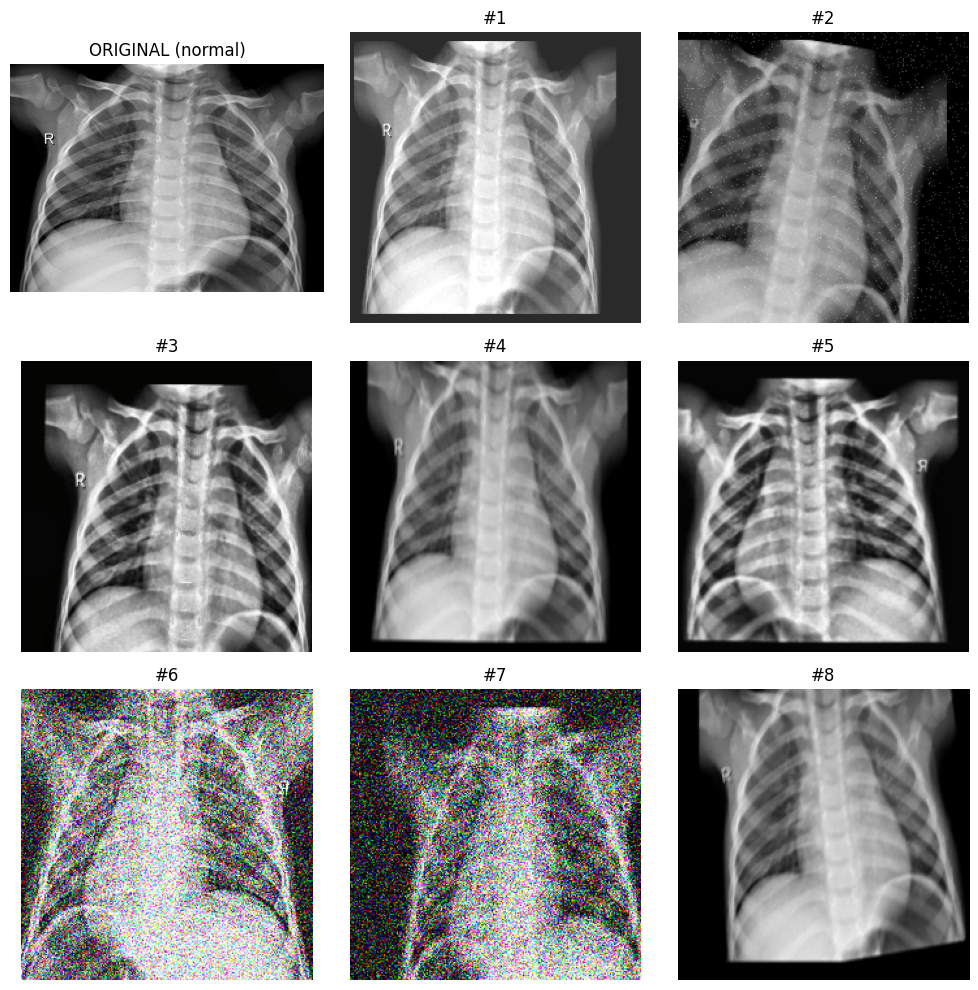

Device: cuda


In [1]:
import json, sys, gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

ROOT = Path.cwd().resolve()
while not (ROOT / "cross_validation.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ipynb.fs.full.preprocessing import get_data_pipeline

FINAL_DIR = ROOT / "results" / "efficientnet" / "final_model"
GRADCAM_DIR = ROOT / "results" / "efficientnet" / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

## 1. Chargement du modèle final

In [2]:
with open(FINAL_DIR / "train_meta.json") as f:
    meta = json.load(f)

NUM_CLASSES = 3
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(FINAL_DIR / meta["weights_file"], map_location=device))
model = model.to(device).eval()

target_layers = [model.features[-1]]
print(f"Couche cible Grad-CAM : {target_layers[0].__class__.__name__}")

Couche cible Grad-CAM : Conv2dNormActivation


## 2. Sélection d'images du test set

On prend `N_SAMPLES` images du test set en couvrant les 3 classes.

In [3]:
N_SAMPLES = 6
pipeline = get_data_pipeline()
test_view = pipeline["test_view"]
test_raw = pipeline["test_raw"]
label_names = pipeline["label_names"]

labels_arr = np.array(test_raw["label"])
selected = []
for cls in sorted(label_names.keys()):
    idxs = np.where(labels_arr == cls)[0][:2]
    selected.extend(idxs.tolist())
selected = selected[:N_SAMPLES]
print(f"Indices sélectionnés : {selected}")

Indices sélectionnés : [0, 1, 234, 235, 264, 289]


## 3. Génération des cartes Grad-CAM

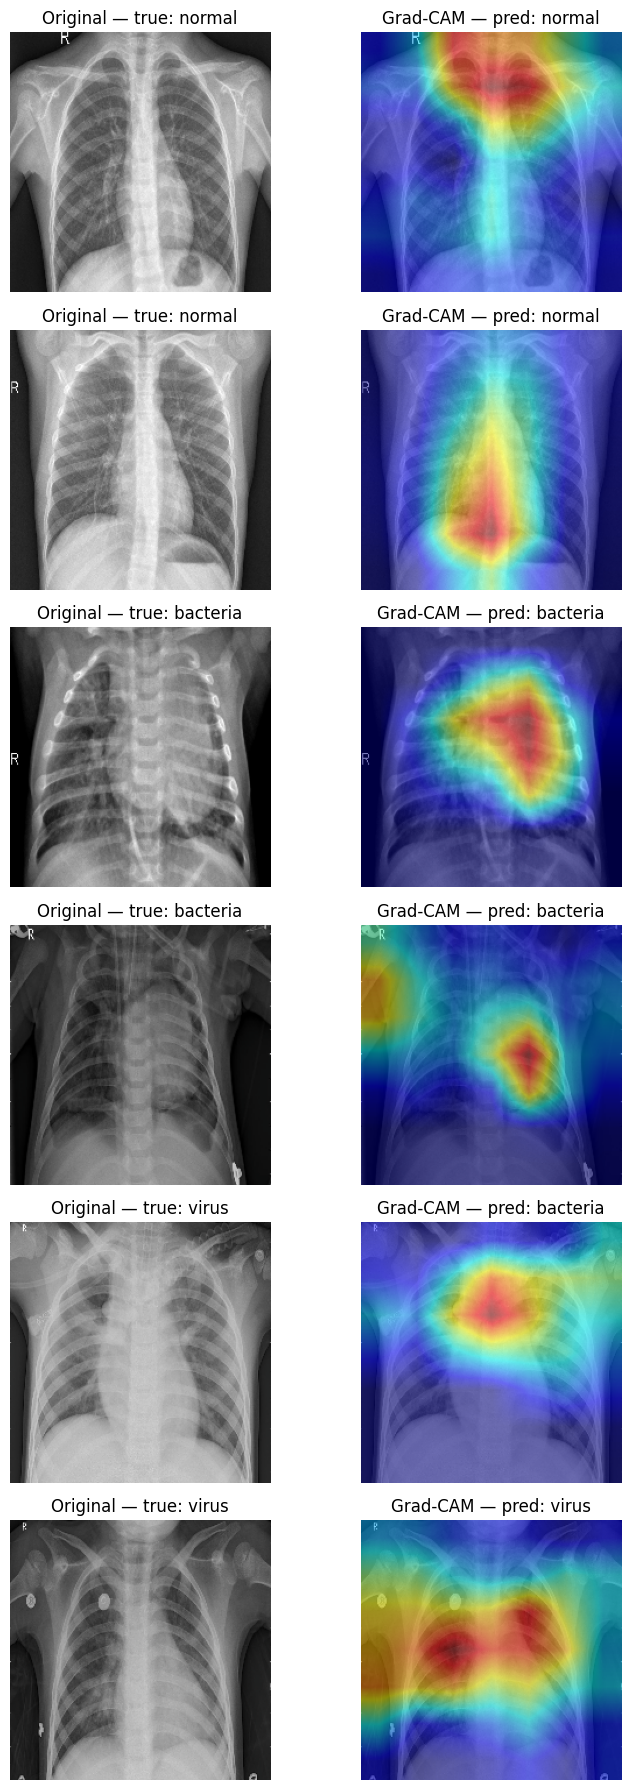

Images sauvegardées dans /media/DATA/Projects/bellinna/Zoidberg2.0/results/efficientnet/gradcam


In [4]:
mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(len(selected), 2, figsize=(8, 3 * len(selected)))
if len(selected) == 1:
    axes = np.array([axes])

for row, idx in enumerate(selected):
    sample = test_view[idx]
    x = sample["image"].unsqueeze(0).to(device)
    true_label = label_names[sample["label"]]

    with torch.no_grad():
        pred = model(x).argmax(1).item()
    pred_label = label_names[pred]

    grayscale = cam(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]

    img = x[0].cpu().numpy().transpose(1, 2, 0) * std + mean
    img = np.clip(img, 0, 1).astype(np.float32)
    overlay = show_cam_on_image(img, grayscale, use_rgb=True)

    axes[row, 0].imshow(img); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"Original — true: {true_label}")
    axes[row, 1].imshow(overlay); axes[row, 1].axis("off")
    axes[row, 1].set_title(f"Grad-CAM — pred: {pred_label}")

    plt.imsave(GRADCAM_DIR / f"gradcam_idx{idx}_true-{true_label}_pred-{pred_label}.png", overlay)

plt.tight_layout()
plt.savefig(GRADCAM_DIR / "gradcam_grid.png", dpi=150)
plt.show()
print(f"Images sauvegardées dans {GRADCAM_DIR}")

del model, cam
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()